# 🧠 Topic Modeling in NLP

## ✅ What is Topic Modeling?

**Topic Modeling** is an unsupervised machine learning technique used in Natural Language Processing (NLP) to automatically identify **hidden themes (topics)** in a collection of text documents.

Each topic is represented as a distribution over words, and each document is a mixture of topics.

---

## 🎯 Why Use Topic Modeling?

- To **explore large text corpora** without labeled data.
- To **summarize and understand** long documents.
- To identify **underlying themes** in customer feedback, news articles, academic papers, etc.
- As a **preprocessing step** for downstream tasks like clustering or classification.

---

## 🌍 Applications of Topic Modeling

| Domain             | Application Example                                        |
|--------------------|------------------------------------------------------------|
| News & Journalism  | Grouping articles by themes (e.g., politics, sports, tech) |
| Business           | Analyzing customer reviews or survey responses             |
| Security & Defense | Detecting narratives in terrorist communication            |
| Academia           | Categorizing research papers by topic                      |
| Marketing          | Understanding market trends via social media               |

---

## 🔧 Common Topic Modeling Algorithms

### 1. **Latent Dirichlet Allocation (LDA)** – *most popular*
- Probabilistic model where:
  - Each document is a mixture of topics.
  - Each topic is a distribution over words.
- Uses Bayesian inference.

### 2. **Non-negative Matrix Factorization (NMF)**
- Linear algebra-based model.
- Factors the document-term matrix into two lower-dimensional non-negative matrices.
- Often works better with **TF-IDF vectors**.

### 3. **LDA2Vec / Top2Vec / BERTopic**
- **LDA2Vec**: Combines LDA with word embeddings.
- **Top2Vec**: Uses semantic embeddings and clustering.
- **BERTopic**: Uses transformer-based embeddings (like BERT) + UMAP + HDBSCAN.

---

## ⚙️ How Does LDA Work?

LDA assumes:

- You have a fixed number of topics (`k`).
- Each document is generated by choosing a set of topics and then sampling words from those topics.

### LDA Process:

1. Randomly assign topics to each word in the corpus.
2. Iterate through each word and:
   - Update its topic assignment based on the surrounding context.
   - Recalculate the probability of the word belonging to each topic.
3. Repeat until convergence.

---

## 📌 Key Parameters in LDA

| Parameter   | Description                                        |
|-------------|----------------------------------------------------|
| `num_topics`| Number of latent topics to discover                |
| `alpha`     | Document-Topic distribution prior (sparsity)       |
| `beta`      | Topic-Word distribution prior (sparsity)           |
| `passes`    | Number of passes through the corpus during training|

---

## 📊 Output of Topic Modeling

- **Topic words**: List of keywords representing each topic.
- **Topic distribution per document**: Probabilities of each topic for every document.
- **Visualizations**: Word clouds, pyLDAvis plots, bar charts, etc.

---

## 🧪 Limitations

- Requires choosing the number of topics in advance.
- Topics can be hard to interpret if data is noisy.
- Works best with longer documents and well-separated topics.

---

*Next: Let’s implement LDA on synthetic terrorism-related news data...*


# Import the Libraries

In [1]:
import pandas as pd
import nltk
import gensim
from gensim import corpora
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\waqar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\waqar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\waqar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Create Terrorist News Related Dataset

In [3]:
#Terrorist Attacks Related News
terrror_news = [
    "A suicide bomber targeted a public market, killing at least 20 civilians.",
    "Gunmen opened fire at a crowded train station in the capital city.",
    "A series of deadly bus attacks launched at downtown late last night.",
    "Explosions were reported near a police checkpoint, causing fatalities.",
    "The militant group claimed responsibility for the deadly bus attack.",
    "A remote-controlled IED exploded near a convoy, injuring several soldiers.",
    "Armed insurgents stormed a village, killing civilians and burning homes.",
    "The attack left dozens dead in a mass shooting at a religious gathering.",
    "Terrorists detonated explosives at a soccer stadium in Turkey, Several people were killed.",
    "Militants launched a rocket attack on the military base overnight.",
    "Security forces launched a raid on a suspected terrorist hideout.",
    "Intelligence agencies foiled a major terror plot in the capital.",
    "Drone strikes eliminated two high-ranking militant leaders in the north.",
    "Police arrested five suspects linked to last month's bombing.",
    "Counter-terrorism units conducted synchronized raids in three cities.",
    "Special forces rescued hostages from an insurgent compound.",
    "Border patrol agents intercepted arms being smuggled across the frontier.",
    "The defense minister praised recent successes in anti-terror operations.",
    "Undercover agents infiltrated a radical cell planning attacks.",
    "Elite forces seized explosives and documents during a night operation.",
    "Authorities uncovered a terror financing ring using cryptocurrency wallets.",
    "The group raised funds via online donations and encrypted messaging apps.",
    "A recent investigation traced illegal cash flows to offshore accounts.",
    "Social media platforms are being exploited for radical recruitment.",
    "Fake charities were found collecting donations for extremist groups.",
    "Hackers linked to a terror group stole digital assets from users.",
    "The suspects were laundering funds through online gaming platforms.",
    "Propaganda videos shared online aim to incite violence and recruit youth.",
    "Digital forensics revealed how influencers spread extremist ideologies.",
    "Counter-financing laws are being tightened to block underground networks."
]

# Create DataFrame
df = pd.DataFrame(terrror_news, columns=['News'])
pd.set_option('display.max_colwidth', None)
df

,News
0,"A suicide bomber targeted a public market, killing at least 20 civilians."
1,Gunmen opened fire at a crowded train station in the capital city.
2,A series of deadly bus attacks launched at downtown late last night.
3,"Explosions were reported near a police checkpoint, causing fatalities."
4,The militant group claimed responsibility for the deadly bus attack.
5,"A remote-controlled IED exploded near a convoy, injuring several soldiers."
6,"Armed insurgents stormed a village, killing civilians and burning homes."
7,The attack left dozens dead in a mass shooting at a religious gathering.
8,"Terrorists detonated explosives at a soccer stadium in Turkey, Several people were killed."
9,Militants launched a rocket attack on the military base overnight.


# Preprocess Text and Convert into Processed Tokens

In [5]:

''' 
    /*------------------------PRE-PROCESSING--DATA -------------
    | Function  : lower() & re.sub()
    | Purpose   : Perform following preprocessing:
    |              • Lower case
    |              • Remove Punctuation marks
    |              • Stopwords Removal
    | Arguments : 
    |       text: Text to be pre-processed
    | Return    :
    |       text: Pre-processed text
    *-----------------------------------------------------------------*/
'''


import re
import string
from nltk.corpus import stopwords


def data_preprocessing(text):
    # Check if 'text' is a string
    if not isinstance(text, str):
        return ""  # Return an empty string if 'text' is not a string

    # Remove all URLs
    text = re.sub(r'http\S+', '', text) 

    # Remove all names starting with @
    text = re.sub(r'@\w+', '', text)

    # Remove all hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove all numeric digits
    text = re.sub(r'\d+', '', text)

    # Remove all punctuation marks
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove all non-alphabetic characters
    text = re.sub(r'[^a-zA-Z]+', ' ', text)

    # Regular expression matches one or more whitespace characters (\s+) and replaces them with a single space (' ')
    text = re.sub(r'\s+', ' ', text)

    # Convert the text to lower case
    text = text.lower()
    
    # Remove all single characters
    text = re.sub(r'\b\w\b', '', text)
        # Remove extra whitespaces after removing single characters 
        
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove words with less than 3 characters
    text = ' '.join(word for word in text.split() if len(word) >= 3) 
    
    # Remove all English Stopwords
    stop_words = stopwords.words('english')
    text = ' '.join(word for word in text.split() if word.lower() not in stop_words)

    return text

# Apply the Preprocessing on Input Data Comments of Training Data
dataset['News'] = dataset['News'].apply(data_preprocessing)

print("\nTraining Data After Pre-processing:")
print("====================================\n")
dataset


Training Data After Pre-processing:



,News
0,suicide bomber targeted public market killing least civilians
1,gunmen opened fire crowded train station capital city
2,series deadly bus attacks launched downtown late last night
3,explosions reported near police checkpoint causing fatalities
4,militant group claimed responsibility deadly bus attack
5,remotecontrolled ied exploded near convoy injuring several soldiers
6,armed insurgents stormed village killing civilians burning homes
7,attack left dozens dead mass shooting religious gathering
8,terrorists detonated explosives soccer stadium turkey several people killed
9,militants launched rocket attack military base overnight


In [9]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    tokens = nltk.word_tokenize(text.lower())  # Lowercase + Tokenize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]  # Lemmatize
    return tokens

# Apply preprocessing to DataFrame
df['Tokens'] = df['News'].apply(preprocess)
df


,News,Tokens
0,suicide bomber targeted public market killing least civilians,"[suicide, bomber, targeted, public, market, killing, least, civilian]"
1,gunmen opened fire crowded train station capital city,"[gunman, opened, fire, crowded, train, station, capital, city]"
2,series deadly bus attacks launched downtown late last night,"[series, deadly, bus, attack, launched, downtown, late, last, night]"
3,explosions reported near police checkpoint causing fatalities,"[explosion, reported, near, police, checkpoint, causing, fatality]"
4,militant group claimed responsibility deadly bus attack,"[militant, group, claimed, responsibility, deadly, bus, attack]"
5,remotecontrolled ied exploded near convoy injuring several soldiers,"[remotecontrolled, ied, exploded, near, convoy, injuring, several, soldier]"
6,armed insurgents stormed village killing civilians burning homes,"[armed, insurgent, stormed, village, killing, civilian, burning, home]"
7,attack left dozens dead mass shooting religious gathering,"[attack, left, dozen, dead, mass, shooting, religious, gathering]"
8,terrorists detonated explosives soccer stadium turkey several people killed,"[terrorist, detonated, explosive, soccer, stadium, turkey, several, people, killed]"
9,militants launched rocket attack military base overnight,"[militant, launched, rocket, attack, military, base, overnight]"


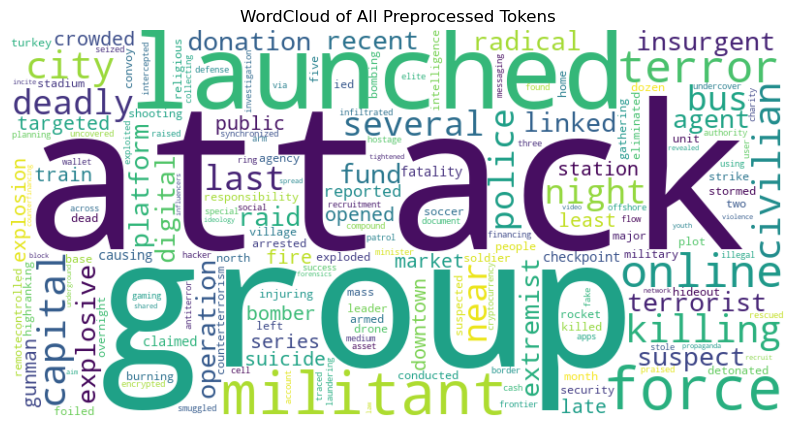

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all tokens into one large string for word cloud
all_words = " ".join([" ".join(tokens) for tokens in df['Tokens']])

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Plot the WordCloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud of All Preprocessed Tokens")
plt.show()

## Create Dictionary & Corpus for Gensim

### 🧾 What is a Dictionary in Gensim?

- A **dictionary** maps every unique word in your dataset to a unique **ID**.
- This is necessary for converting words into a numerical format that topic modeling algorithms can work with.

📌 Example:
If your corpus has the words: `["bomb", "attack", "security"]`  
Then the dictionary may look like:  
```python
{'bomb': 0, 'attack': 1, 'security': 2}


### 📦 What is a Corpus in Gensim?

The **corpus** is a list of **Bag-of-Words (BoW)** representations of your documents.

Each document is represented as a list of `(word_id, word_count)` tuples, based on the `dictionary`.

---

📌 **Example:**

If a document contains the words:  
`"bomb attack attack"`

And the dictionary is:
```python
{'bomb': 0, 'attack': 1}


### [(0, 1), (1, 2)]  # word_id 0 ('bomb') appears once, word_id 1 ('attack') appears twice

In [13]:
# Create Dictionary and Corpus
from gensim import corpora
dictionary = corpora.Dictionary(df['Tokens'])


corpus = [dictionary.doc2bow(text) for text in df['Tokens']]

print(f"Unique tokens: {len(dictionary)}")
print(f"Number of documents: {len(corpus)}")


Unique tokens: 182
Number of documents: 30


# Train LDA Model

Now that we have the **dictionary** and **corpus**, we can train the **Latent Dirichlet Allocation (LDA)** model using Gensim.

---

### 🔧 What is LDA?

**Latent Dirichlet Allocation (LDA)** is a generative probabilistic model that:

- Assumes each **document is a mixture of topics**.
- Assumes each **topic is a mixture of words**.
- Learns these topic and word distributions from the data.

LDA uncovers the **hidden thematic structure** in the corpus.

---

### 📥 Inputs to Gensim's `LdaModel`:

| Parameter        | Description                                                              |
|------------------|--------------------------------------------------------------------------|
| `corpus`         | Bag-of-Words representation of all documents                            |
| `id2word`        | Dictionary mapping word IDs back to actual words                        |
| `num_topics`     | Number of topics the model should learn                                 |
| `passes`         | Number of passes through the corpus during training                     |
| `random_state`   | Seed for reproducibility                                                 |

---

### 📤 Output of the LDA Model:

- A trained model object that contains:
  - Topic-word distributions
  - Document-topic distributions
- Each topic will be represented by a list of **keywords** with associated **weights** (probabilities).
- You can use `.print_topics()` to display the top keywords per topic.

---

### 🧪 Tip:
Increasing the number of `passes` may lead to better model convergence, but it will take more time.

Next, we’ll display the top words from each topic to see what themes the model has learned!


In [17]:
# Train LDA model
lda_model = gensim.models.LdaModel(corpus=corpus,
                                   id2word=dictionary,
                                   num_topics=3,
                                   random_state=100,
                                   update_every=1,
                                   chunksize=10,
                                   passes=200,
                                   iterations=500, # More iterations
                                   alpha='asymmetric', # Helps separate dominant topics
                                   per_word_topics=True)

# Print top words per topic
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic #{idx}: {topic}")

Topic #0: 0.046*"attack" + 0.021*"launched" + 0.021*"militant" + 0.020*"civilian" + 0.020*"killing" + 0.020*"bus" + 0.020*"deadly" + 0.012*"insurgent" + 0.012*"capital" + 0.012*"city"
Topic #1: 0.022*"online" + 0.022*"group" + 0.015*"terror" + 0.015*"donation" + 0.015*"digital" + 0.015*"fund" + 0.015*"extremist" + 0.015*"platform" + 0.009*"recent" + 0.009*"linked"
Topic #2: 0.024*"force" + 0.017*"operation" + 0.017*"raid" + 0.017*"agent" + 0.010*"frontier" + 0.010*"across" + 0.010*"intercepted" + 0.010*"smuggled" + 0.010*"arm" + 0.010*"patrol"


# Word Clouds for Topics

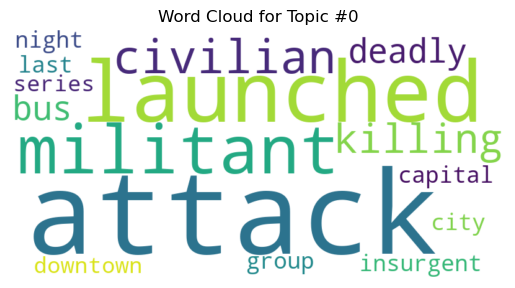

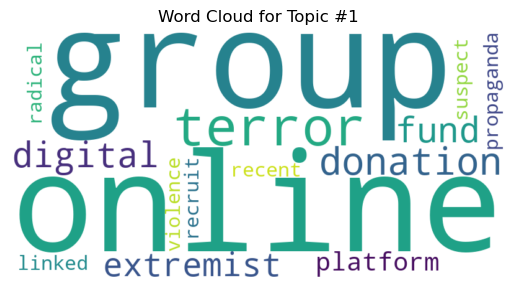

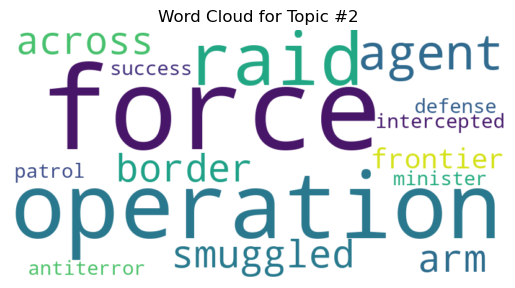

In [19]:
# Word Clouds for Topics
for t in range(lda_model.num_topics):
    plt.figure()
    plt.title(f"Word Cloud for Topic #{t}")
    wc = WordCloud(background_color='white',
                   width=800,
                   height=400,
                   max_words=20).generate_from_frequencies(dict(lda_model.show_topic(t, 15)))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()


# Assign Dominant Topic to Each News

In [21]:
# Function to get dominant topic
def get_dominant_topic(ldamodel, bow):
    topic_probs = ldamodel.get_document_topics(bow)
    return max(topic_probs, key=lambda x: x[1])[0]

# Assign dominant topic to each row
df['Dominant_Topic'] = [get_dominant_topic(lda_model, bow) for bow in corpus]
df

,News,Tokens,Dominant_Topic
0,suicide bomber targeted public market killing least civilians,"[suicide, bomber, targeted, public, market, killing, least, civilian]",0
1,gunmen opened fire crowded train station capital city,"[gunman, opened, fire, crowded, train, station, capital, city]",0
2,series deadly bus attacks launched downtown late last night,"[series, deadly, bus, attack, launched, downtown, late, last, night]",0
3,explosions reported near police checkpoint causing fatalities,"[explosion, reported, near, police, checkpoint, causing, fatality]",1
4,militant group claimed responsibility deadly bus attack,"[militant, group, claimed, responsibility, deadly, bus, attack]",0
5,remotecontrolled ied exploded near convoy injuring several soldiers,"[remotecontrolled, ied, exploded, near, convoy, injuring, several, soldier]",2
6,armed insurgents stormed village killing civilians burning homes,"[armed, insurgent, stormed, village, killing, civilian, burning, home]",0
7,attack left dozens dead mass shooting religious gathering,"[attack, left, dozen, dead, mass, shooting, religious, gathering]",1
8,terrorists detonated explosives soccer stadium turkey several people killed,"[terrorist, detonated, explosive, soccer, stadium, turkey, several, people, killed]",1
9,militants launched rocket attack military base overnight,"[militant, launched, rocket, attack, military, base, overnight]",0


# Add top keywords for each topic

In [23]:
# Also add top keywords for each topic
topic_keywords = {i: ", ".join([word for word, prob in lda_model.show_topic(i)]) for i in range(3)}
df['Topic_keywords'] = df['Dominant_Topic'].map(topic_keywords)

df

,News,Tokens,Dominant_Topic,Topic_keywords
0,suicide bomber targeted public market killing least civilians,"[suicide, bomber, targeted, public, market, killing, least, civilian]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"
1,gunmen opened fire crowded train station capital city,"[gunman, opened, fire, crowded, train, station, capital, city]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"
2,series deadly bus attacks launched downtown late last night,"[series, deadly, bus, attack, launched, downtown, late, last, night]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"
3,explosions reported near police checkpoint causing fatalities,"[explosion, reported, near, police, checkpoint, causing, fatality]",1,"online, group, terror, donation, digital, fund, extremist, platform, recent, linked"
4,militant group claimed responsibility deadly bus attack,"[militant, group, claimed, responsibility, deadly, bus, attack]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"
5,remotecontrolled ied exploded near convoy injuring several soldiers,"[remotecontrolled, ied, exploded, near, convoy, injuring, several, soldier]",2,"force, operation, raid, agent, frontier, across, intercepted, smuggled, arm, patrol"
6,armed insurgents stormed village killing civilians burning homes,"[armed, insurgent, stormed, village, killing, civilian, burning, home]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"
7,attack left dozens dead mass shooting religious gathering,"[attack, left, dozen, dead, mass, shooting, religious, gathering]",1,"online, group, terror, donation, digital, fund, extremist, platform, recent, linked"
8,terrorists detonated explosives soccer stadium turkey several people killed,"[terrorist, detonated, explosive, soccer, stadium, turkey, several, people, killed]",1,"online, group, terror, donation, digital, fund, extremist, platform, recent, linked"
9,militants launched rocket attack military base overnight,"[militant, launched, rocket, attack, military, base, overnight]",0,"attack, launched, militant, civilian, killing, bus, deadly, insurgent, capital, city"


# Compute the Coherence Score of Model

In [25]:
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(model=lda_model,
                                     texts=df['Tokens'],
                                     dictionary=dictionary,
                                     coherence='c_v')

coherence_score = coherence_model_lda.get_coherence()
print(f"\n📊 Coherence Score (c_v): {coherence_score:.4f}")


📊 Coherence Score (c_v): 0.4034


# 📊 Bar Charts: Word Counts of Topic Keywords

After visualizing the overall vocabulary using a WordCloud, it's useful to examine the **top keywords for each topic** more precisely.

This bar chart helps us understand:
- Which words are most **strongly associated** with each topic.
- How important each word is to the topic (via **probability weights**).


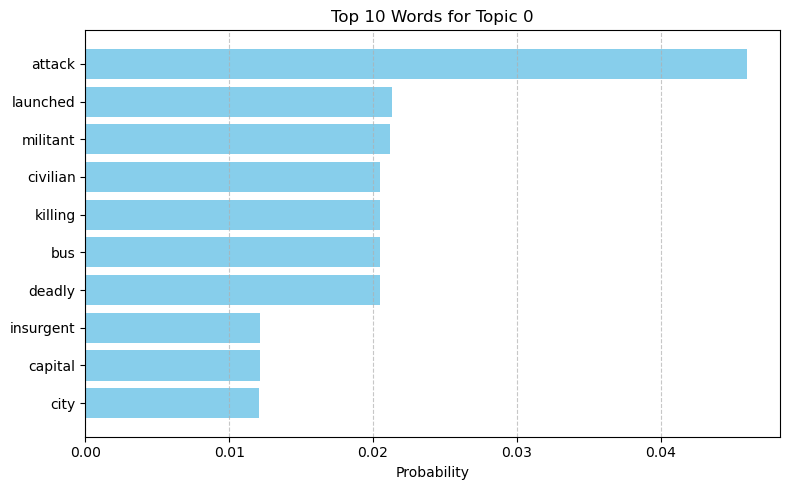

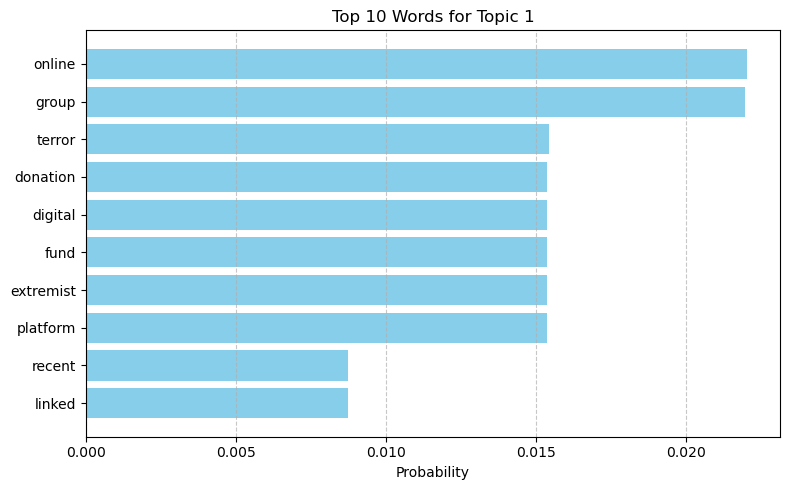

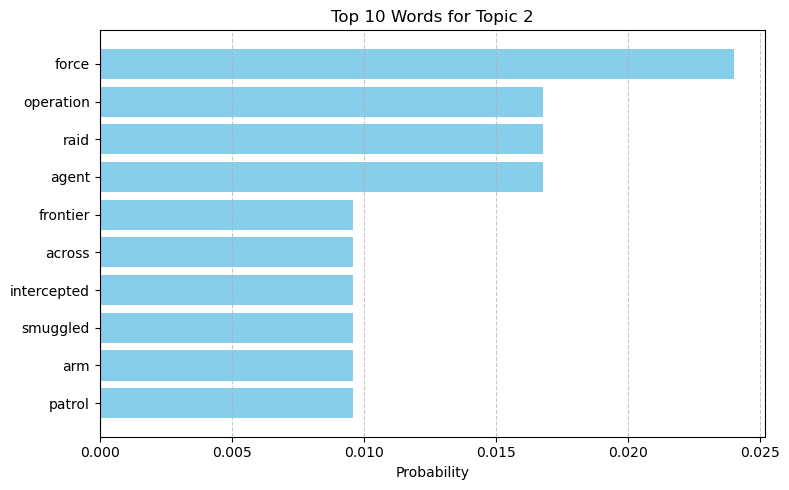

In [27]:
import matplotlib.pyplot as plt

# Plot Top N keywords per topic using bar charts
TOP_N = 10  # Number of words to display per topic

for topic_id in range(lda_model.num_topics):
    # Get top N keywords and their weights
    topic_words = lda_model.show_topic(topic_id, topn=TOP_N)
    words = [word for word, prob in topic_words]
    weights = [prob for word, prob in topic_words]
    
    # Plot
    plt.figure(figsize=(8, 5))
    plt.barh(words[::-1], weights[::-1], color='skyblue')  # Reverse for top-down display
    plt.xlabel("Probability")
    plt.title(f"Top {TOP_N} Words for Topic {topic_id}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


## 📍 Intertopic Distance Map (LDA Visualization)

The **Intertopic Distance Map** is a visual tool that helps interpret and evaluate LDA topic models. It is typically generated using the `pyLDAvis` library in Python and is used to:

- Understand how topics **relate to each other**
- Explore the **content of each topic**
- Identify **redundant or overlapping** topics

---

### 🎯 Key Components of the Map

#### 🔘 1. Circles on the Left Panel:
- Each circle represents a **topic**.
- The **size** of the circle reflects the **prevalence** of that topic in the corpus.
- The **distance** between circles reflects their **semantic similarity**:
  - Topics that are close together share many common words.
  - Topics that are far apart are more distinct.

#### 📊 2. Bar Chart on the Right Panel:
- Displays the **top words** for the selected topic.
- Shows both:
  - **Overall frequency** of the word in the corpus (gray bars)
  - **Frequency within the selected topic** (red bars)

#### 🎚 3. Relevance Slider:
- Adjusts how the top keywords are selected and ranked.
- A relevance value of:
  - **1.0**: Shows words most **unique to the topic** (i.e., high "purity")
  - **0.0**: Shows words most **frequent overall**
  - Values in between balance **exclusivity** and **frequency**

---

### 🧠 Why It's Useful

- Helps you **visually validate** your topic model.
- Lets you quickly detect:
  - Overlapping or redundant topics
  - Dominant topics
  - Whether topics are **well-separated** (which is desirable)
- Makes it easier to **interpret topic meaning** based on their keywords.

---

### 📌 Tip:
- A **good model** will often show **well-separated** (non-overlapping) topic circles.
- If many circles are stacked or overlapping, your model may have too many or too few topics.

---


In [29]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis  # for gensim > 4.0

# Prepare the visualization
pyldavis_data = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(pyldavis_data)
